In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest

In [2]:
df = pd.read_csv('ab_test_data.csv')

In [3]:
df.head()

,user_id,timestamp,test_group,conversion
0,7f6833e6-1141-4f20-b4b2-f1e31019b1fd,2023-07-04 04:40:55.848109,a,0
1,e6a6e960-d3f3-4074-a516-ba1e609b211e,2023-07-06 00:26:45.486187,b,0
2,4d3fbfa5-6847-410a-bac2-477f01d5f400,2023-07-10 20:24:33.639464,b,0
3,361457d9-a044-48f7-981c-d67dc3861679,2023-07-20 07:04:49.957013,b,0
4,285cd63d-7d03-427f-a062-1fa2dd2e77d6,2023-07-19 23:27:50.116680,b,0


In [4]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['test_group'] = df['test_group'].astype('category')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19998 entries, 0 to 19997
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     19998 non-null  str           
 1   timestamp   19998 non-null  datetime64[us]
 2   test_group  19998 non-null  category      
 3   conversion  19998 non-null  int64         
dtypes: category(1), datetime64[us](1), int64(1), str(1)
memory usage: 488.4 KB


In [5]:
users = df['test_group'].value_counts()
users

test_group
a    10013
b     9985
Name: count, dtype: int64

In [6]:
conversions = df.groupby('test_group')['conversion'].sum()
conversions

test_group
a    611
b    889
Name: conversion, dtype: int64

In [7]:
cr = conversions/users
cr

test_group
a    0.061021
b    0.089034
dtype: float64

In [8]:
print(f'start_date {df['timestamp'].min().date()}')
print(f'end_date { df['timestamp'].max().date()}')

start_date 2023-07-03
end_date 2023-07-25


In [9]:
#df.groupby('test_group')['timestamp'].agg(['min', 'max', lambda x: x.max() - x.min()])

In [10]:
print(f'duration  {(df['timestamp'].max() - df['timestamp'].min()).days} днів')

duration  21 днів


In [11]:
conv_A = df[df['test_group'] == 'a']['conversion'].sum()
print(conv_A)
conv_B = df[df['test_group'] == 'b']['conversion'].sum()
print(conv_B)

611
889


In [12]:
n_A = df[df['test_group'] == 'a'].shape[0]
print(n_A)
n_B = df[df['test_group'] == 'b'].shape[0]
print(n_B)

10013
9985


In [13]:
z_stat, p_value = proportions_ztest(count = [conv_A, conv_B], nobs = [n_A, n_B])
print(f"Z-статистика: {z_stat:}")
print(f"p-value: {p_value:}")

Z-статистика: -7.519675939906207
p-value: 5.491217728445103e-14


In [14]:
if p_value < 0.05:
    print(f'Відхиляємо нульову гіпотезу')
else:
    print(f'Недостатньо доказів для відхилення')

Відхиляємо нульову гіпотезу


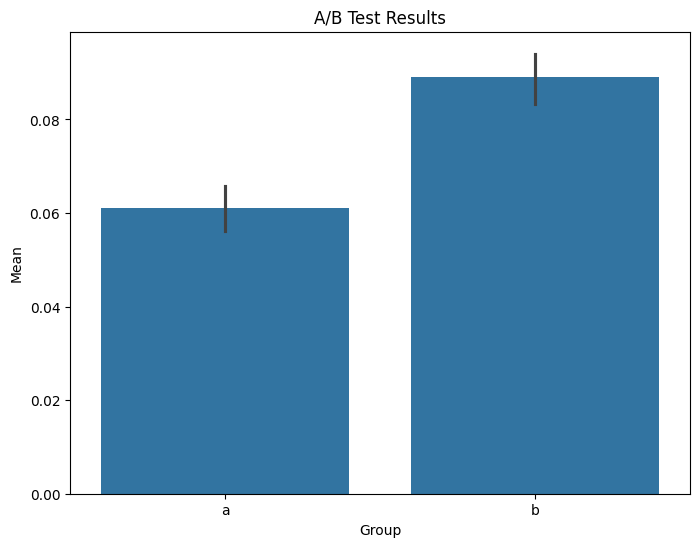

In [15]:
plt.figure(figsize=(8, 6))
sns.barplot(x=df['test_group'], 
            y=df['conversion'], 
            errorbar=('ci', 95))

plt.title('A/B Test Results')
plt.xlabel('Group')
plt.ylabel('Mean')

plt.show()

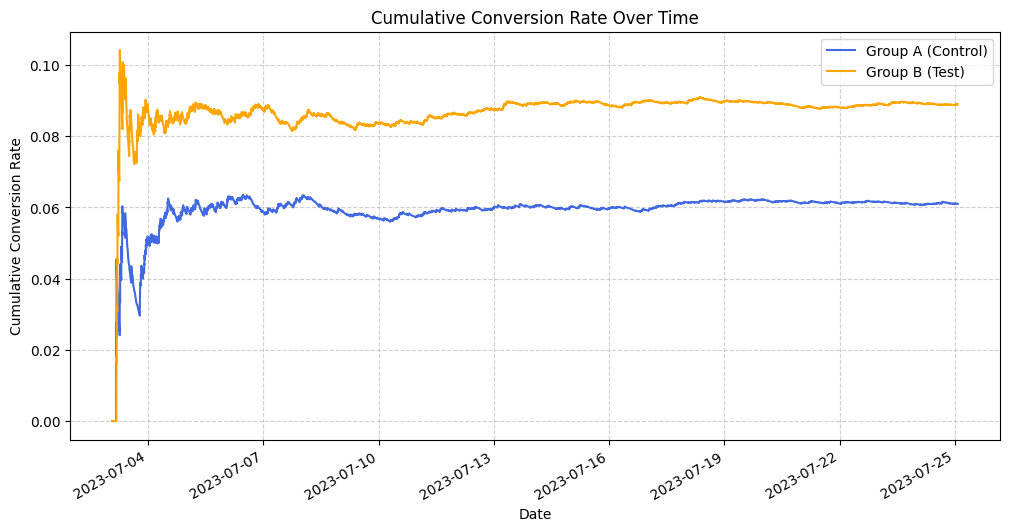

In [16]:
import matplotlib.dates as mdates

sort_test = df.sort_values(by='timestamp').reset_index(drop=True)

cum_a = sort_test[sort_test['test_group'] == 'a'].copy()
cum_b = sort_test[sort_test['test_group'] == 'b'].copy()

cum_a['cum_cr'] = cum_a['conversion'].expanding().mean()
cum_b['cum_cr'] = cum_b['conversion'].expanding().mean()

plt.figure(figsize=(12, 6))

plt.plot(cum_a['timestamp'], cum_a['cum_cr'], label='Group A (Control)', color='royalblue')
plt.plot(cum_b['timestamp'], cum_b['cum_cr'], label='Group B (Test)', color='orange')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) 
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=3))    
plt.gcf().autofmt_xdate() 

plt.title('Cumulative Conversion Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Cumulative Conversion Rate')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()